# Week-26

ecosystem_palette = {
    "Lakes": "#00A6D6",                    # bright cyan-blue
    "Streams": "#006D2C",                  # dark forest green
    "Marine": "#08306B",                   # deep navy
    "Terrestrial aboveground": "#7AC943",  # bright leaf green
    "Terrestrial belowground": "#6B3A19",  # dark soil brown
}

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "F1": "#E6AB02",        # mustard
    "MCC": "#B2182B",       # deep red / burgundy
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

version_palette = {
    "Original": "#bab6f2",
    "Directed": "#6edeed",
    "Directed-Negative": "#1f78b4",
}

network_type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

## TrainRatio 60: web-level equivalence results

,Metric,Population,N webs,Empirical mean,Pseudo mean,Mean delta,Relative bias (%),90% CI relative error,Eq +/-10%,Eq +/-20%,Eq +/-30%
0,Connectance,PrimaryMean20,290,0.1324,0.1126,-0.0198,-15.20,"[-16.04%, -14.37%]",No,Yes,Yes
1,Mean generality,PrimaryMean20,290,10.5377,9.0045,-1.5332,-11.68,"[-12.59%, -10.76%]",No,Yes,Yes
2,Mean vulnerability,PrimaryMean20,290,8.2904,7.1972,-1.0932,-10.44,"[-11.33%, -9.55%]",No,Yes,Yes
3,Mean trophic height (>=10 valid runs),ConditionalAtLeast10ValidRuns,289,2.6438,3.0399,+0.3961,+12.12,"[9.55%, 14.68%]",No,Yes,Yes
4,Mean trophic height (20/20 sensitivity),Complete20Sensitivity,184,2.4681,2.6146,+0.1464,+5.12,"[3.77%, 6.47%]",Yes,Yes,Yes


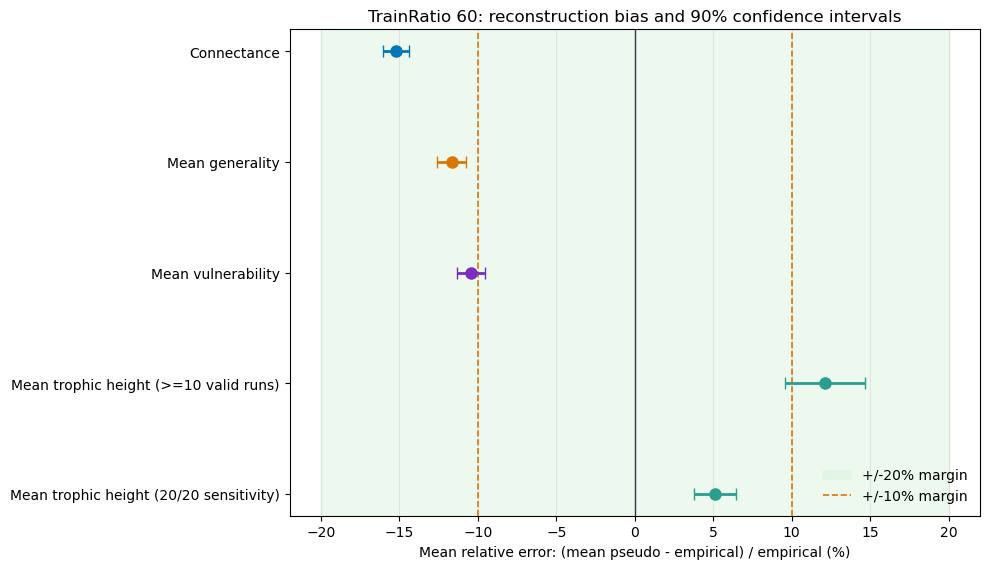

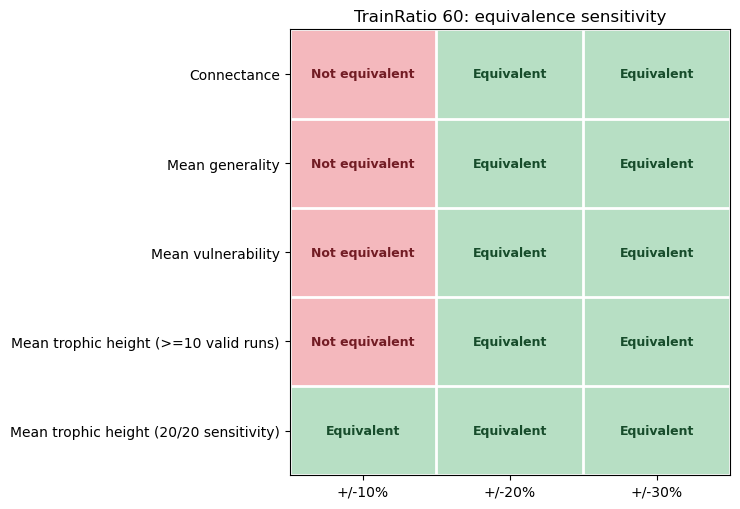

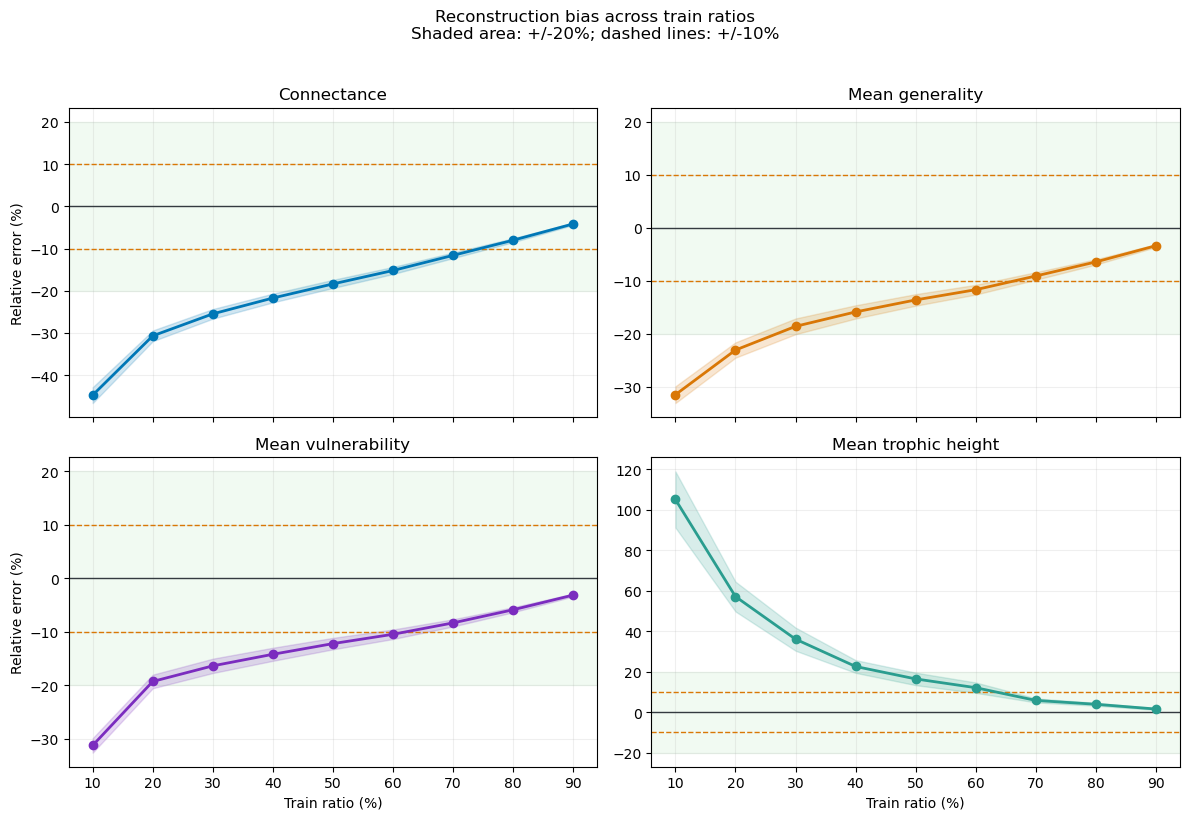

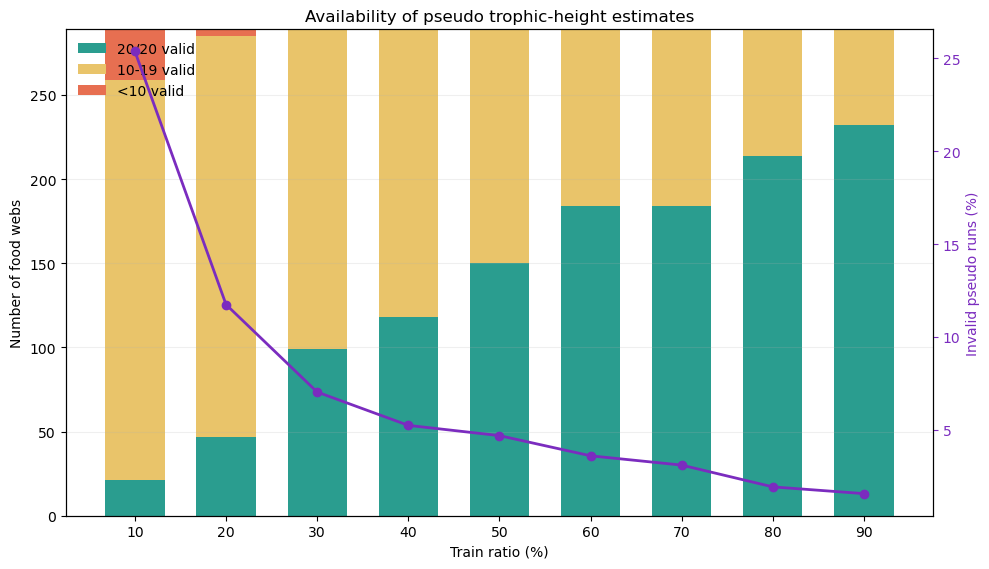

## Trophic-height discrepancies with Lachlan

,Food web,Ecosystem,MATLAB log,Lachlan,Difference,MATLAB species,Lachlan species
53,Carpinteria,terrestrial aboveground,8.2526,6.7514,+1.5012,160,160
55,Chesapeake Bay,marine,4.7052,3.4081,+1.2971,521,521
271,Sutton Stream,streams,2.1089,2.0712,+0.0377,88,87
30,Blackrock Stream,streams,2.1594,2.1378,+0.0216,88,87
105,Gearagh,terrestrial belowground,2.7244,2.7260,-0.0016,117,116


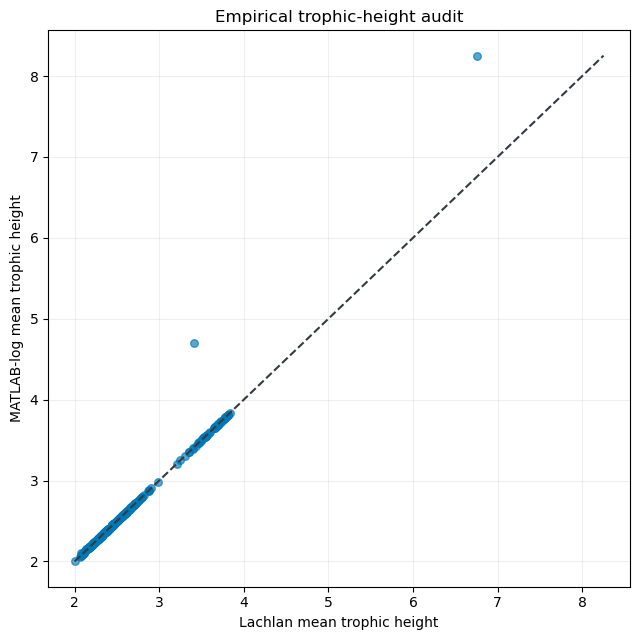

## Empirical reference values

,Reference,Metric,SourceMetric,NumFoodWebs,Mean,SD,SEM,SDPercentOfMean,SEMPercentOfMean
0,WLNMLogs,Connectance,Connectance,290,0.1324,0.0473,0.0028,35.69%,2.10%
1,WLNMLogs,MeanGenerality,MeanGenerality,290,10.5377,7.3473,0.4315,69.72%,4.09%
2,WLNMLogs,MeanVulnerability,MeanVulnerability,290,8.2904,5.6076,0.3293,67.64%,3.97%
3,WLNMLogs,MeanTrophicHeight,NetworkXMeanTrophicLevel,289,2.6438,0.6028,0.0355,22.80%,1.34%
4,LachlanMeanTLCSV,MeanTrophicHeight,NetworkX trophic_levels plus Lachlan postprocessing,289,2.6340,0.5478,0.0322,20.80%,1.22%


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display, Markdown


# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src" / "matlab").exists():
            return candidate
    raise FileNotFoundError("Could not locate qmul-phd-framework repository root.")


ROOT = find_repo_root()
ATHEN_DIR = (
    ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita"
    / "statistical_tests/athen"
)

eq60 = pd.read_csv(ATHEN_DIR / "athen_equivalence_sensitivity_train60.csv")
eq_all = pd.read_csv(ATHEN_DIR / "athen_equivalence_sensitivity_all_ratios.csv")
metric60 = pd.read_csv(ATHEN_DIR / "athen_metric_summary_train60.csv")
validity = pd.read_csv(ATHEN_DIR / "athen_trophic_height_validity.csv")
audit = pd.read_csv(ATHEN_DIR / "athen_trophic_height_lachlan_audit.csv")
references = pd.read_csv(ATHEN_DIR / "athen_empirical_reference_summary.csv")

METRIC_LABELS = {
    "Connectance": "Connectance",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
    "MeanTrophicHeight": "Mean trophic height",
}

METRIC_COLORS = {
    "Connectance": "#0077b6",
    "MeanGenerality": "#d97706",
    "MeanVulnerability": "#7b2cbf",
    "MeanTrophicHeight": "#2a9d8f",
}

SAVE_FIGURES = False
FIGURE_DIR = ATHEN_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)


def finish_figure(fig, filename):
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


# ---------------------------------------------------------------------
# TrainRatio 60 summary table
# ---------------------------------------------------------------------
primary_mask = (
    (eq60["AnalysisPopulation"] == "PrimaryMean20")
    | (eq60["AnalysisPopulation"] == "ConditionalAtLeast10ValidRuns")
    | (
        (eq60["Metric"] == "MeanTrophicHeight")
        & (eq60["AnalysisPopulation"] == "Complete20Sensitivity")
    )
)

selected60 = eq60.loc[primary_mask].copy()

selected60["DisplayMetric"] = selected60["Metric"].map(METRIC_LABELS)
selected60.loc[
    selected60["AnalysisPopulation"] == "ConditionalAtLeast10ValidRuns",
    "DisplayMetric",
] = "Mean trophic height (>=10 valid runs)"
selected60.loc[
    selected60["AnalysisPopulation"] == "Complete20Sensitivity",
    "DisplayMetric",
] = "Mean trophic height (20/20 sensitivity)"

descriptive = (
    selected60
    .drop_duplicates(["DisplayMetric", "AnalysisPopulation"])
    [[
        "DisplayMetric",
        "AnalysisPopulation",
        "NumFoodWebs",
        "MeanEmpirical",
        "MeanPseudo",
        "MeanDelta",
        "MeanRelativeErrorPercent",
        "RelativeCI90LowerPercent",
        "RelativeCI90UpperPercent",
    ]]
    .copy()
)

descriptive["90% CI relative error"] = descriptive.apply(
    lambda row: (
        f"[{row['RelativeCI90LowerPercent']:.2f}%, "
        f"{row['RelativeCI90UpperPercent']:.2f}%]"
    ),
    axis=1,
)

sensitivity = selected60.pivot(
    index="DisplayMetric",
    columns="MarginPercent",
    values="Equivalent",
).reset_index()

sensitivity = sensitivity.rename(
    columns={
        10.0: "Eq +/-10%",
        20.0: "Eq +/-20%",
        30.0: "Eq +/-30%",
    }
)

summary_table = descriptive.merge(sensitivity, on="DisplayMetric", how="left")
summary_table = summary_table.rename(
    columns={
        "DisplayMetric": "Metric",
        "AnalysisPopulation": "Population",
        "NumFoodWebs": "N webs",
        "MeanEmpirical": "Empirical mean",
        "MeanPseudo": "Pseudo mean",
        "MeanDelta": "Mean delta",
        "MeanRelativeErrorPercent": "Relative bias (%)",
    }
)

eq_columns = ["Eq +/-10%", "Eq +/-20%", "Eq +/-30%"]
for column in eq_columns:
    summary_table[column] = summary_table[column].map({1: "Yes", 0: "No"})


def shade_equivalence(column):
    return [
        (
            "background-color: #d8f3dc; color: #174c2b; font-weight: 600"
            if value == "Yes"
            else "background-color: #f8d7da; color: #721c24; font-weight: 600"
        )
        for value in column
    ]


display(Markdown("## TrainRatio 60: web-level equivalence results"))

styled_summary = (
    summary_table[
        [
            "Metric",
            "Population",
            "N webs",
            "Empirical mean",
            "Pseudo mean",
            "Mean delta",
            "Relative bias (%)",
            "90% CI relative error",
            *eq_columns,
        ]
    ]
    .style
    .format(
        {
            "Empirical mean": "{:.4f}",
            "Pseudo mean": "{:.4f}",
            "Mean delta": "{:+.4f}",
            "Relative bias (%)": "{:+.2f}",
        }
    )
    .apply(shade_equivalence, subset=eq_columns)
)

display(styled_summary)


# ---------------------------------------------------------------------
# Figure 1: Forest plot for TrainRatio 60
# ---------------------------------------------------------------------
forest = selected60[selected60["MarginPercent"] == 20].copy()

plot_order = [
    "Connectance",
    "Mean generality",
    "Mean vulnerability",
    "Mean trophic height (>=10 valid runs)",
    "Mean trophic height (20/20 sensitivity)",
]

forest["PlotOrder"] = forest["DisplayMetric"].map(
    {name: index for index, name in enumerate(plot_order)}
)
forest = forest.sort_values("PlotOrder", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5.8))

ax.axvspan(-20, 20, color="#d8f3dc", alpha=0.45, label="+/-20% margin")
ax.axvline(-10, color="#d97706", linestyle="--", linewidth=1.2)
ax.axvline(10, color="#d97706", linestyle="--", linewidth=1.2, label="+/-10% margin")
ax.axvline(0, color="#343a40", linewidth=1)

for y, (_, row) in enumerate(forest.iterrows()):
    mean = row["MeanRelativeErrorPercent"]
    lower = row["RelativeCI90LowerPercent"]
    upper = row["RelativeCI90UpperPercent"]
    color = METRIC_COLORS[row["Metric"]]

    ax.errorbar(
        mean,
        y,
        xerr=[[mean - lower], [upper - mean]],
        fmt="o",
        color=color,
        ecolor=color,
        markersize=8,
        capsize=4,
        linewidth=2,
    )

ax.set_yticks(range(len(forest)))
ax.set_yticklabels(forest["DisplayMetric"])
ax.set_xlabel("Mean relative error: (mean pseudo - empirical) / empirical (%)")
ax.set_title("TrainRatio 60: reconstruction bias and 90% confidence intervals")
ax.grid(axis="x", alpha=0.25)
ax.legend(frameon=False, loc="lower right")

finish_figure(fig, "athen_train60_relative_error_forest.png")


# ---------------------------------------------------------------------
# Figure 2: Equivalence sensitivity matrix at TrainRatio 60
# ---------------------------------------------------------------------
heat = selected60.pivot(
    index="DisplayMetric",
    columns="MarginPercent",
    values="Equivalent",
).reindex(plot_order)

heat = heat[[10.0, 20.0, 30.0]]

fig, ax = plt.subplots(figsize=(7.5, 5.2))
cmap = ListedColormap(["#f4b8bd", "#b7dfc4"])

ax.imshow(heat.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels([f"+/-{int(value)}%" for value in heat.columns])
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title("TrainRatio 60: equivalence sensitivity")

for row_index in range(heat.shape[0]):
    for column_index in range(heat.shape[1]):
        value = int(heat.iloc[row_index, column_index])
        ax.text(
            column_index,
            row_index,
            "Equivalent" if value else "Not equivalent",
            ha="center",
            va="center",
            fontsize=9,
            color="#174c2b" if value else "#721c24",
            fontweight="bold",
        )

ax.set_xticks(np.arange(-0.5, len(heat.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heat.index), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

finish_figure(fig, "athen_train60_equivalence_sensitivity.png")


# ---------------------------------------------------------------------
# Figure 3: Relative bias across all train ratios
# ---------------------------------------------------------------------
trend = eq_all[
    (eq_all["MarginPercent"] == 20)
    & (eq_all["AnalysisPopulation"] != "Complete20Sensitivity")
].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for ax, metric in zip(axes, METRIC_LABELS):
    data = trend[trend["Metric"] == metric].sort_values("TrainRatio")
    color = METRIC_COLORS[metric]

    ax.axhspan(-20, 20, color="#d8f3dc", alpha=0.35)
    ax.axhline(-10, color="#d97706", linestyle="--", linewidth=1)
    ax.axhline(10, color="#d97706", linestyle="--", linewidth=1)
    ax.axhline(0, color="#343a40", linewidth=1)

    ax.plot(
        data["TrainRatio"],
        data["MeanRelativeErrorPercent"],
        color=color,
        marker="o",
        linewidth=2,
    )
    ax.fill_between(
        data["TrainRatio"],
        data["RelativeCI90LowerPercent"],
        data["RelativeCI90UpperPercent"],
        color=color,
        alpha=0.18,
    )

    ax.set_title(METRIC_LABELS[metric])
    ax.set_xticks(range(10, 100, 10))
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Relative error (%)")
axes[2].set_ylabel("Relative error (%)")
axes[2].set_xlabel("Train ratio (%)")
axes[3].set_xlabel("Train ratio (%)")

fig.suptitle(
    "Reconstruction bias across train ratios\n"
    "Shaded area: +/-20%; dashed lines: +/-10%",
    y=1.02,
)

finish_figure(fig, "athen_relative_error_all_train_ratios.png")


# ---------------------------------------------------------------------
# Figure 4: Trophic-height data validity
# ---------------------------------------------------------------------
validity = validity.sort_values("TrainRatio").copy()
validity["PseudoMetricInvalidPercent"] = (
    100
    * validity["PseudoMetricInvalidRuns"]
    / (validity["PseudoMetricValidRuns"] + validity["PseudoMetricInvalidRuns"])
)

fig, ax = plt.subplots(figsize=(10, 5.8))

x = np.arange(len(validity))
width = 0.65

ax.bar(
    x,
    validity["Complete20FoodWebs"],
    width,
    label="20/20 valid",
    color="#2a9d8f",
)
ax.bar(
    x,
    validity["Partial10To19FoodWebs"],
    width,
    bottom=validity["Complete20FoodWebs"],
    label="10-19 valid",
    color="#e9c46a",
)
ax.bar(
    x,
    validity["Below10ValidFoodWebs"],
    width,
    bottom=(
        validity["Complete20FoodWebs"]
        + validity["Partial10To19FoodWebs"]
    ),
    label="<10 valid",
    color="#e76f51",
)

ax.set_xticks(x)
ax.set_xticklabels(validity["TrainRatio"].astype(int))
ax.set_xlabel("Train ratio (%)")
ax.set_ylabel("Number of food webs")
ax.set_title("Availability of pseudo trophic-height estimates")
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="y", alpha=0.2)

ax2 = ax.twinx()
ax2.plot(
    x,
    validity["PseudoMetricInvalidPercent"],
    color="#7b2cbf",
    marker="o",
    linewidth=2,
    label="Invalid pseudo runs (%)",
)
ax2.set_ylabel("Invalid pseudo runs (%)", color="#7b2cbf")
ax2.tick_params(axis="y", colors="#7b2cbf")

finish_figure(fig, "athen_trophic_height_validity.png")


# ---------------------------------------------------------------------
# Figure 5: MATLAB logs versus Lachlan trophic-height values
# ---------------------------------------------------------------------
audit_valid = audit[
    audit["LogEmpiricalTrophicHeight"].notna()
    & audit["LachlanTrophicHeight"].notna()
].copy()

mismatches = (
    audit_valid[audit_valid["AbsoluteDifference"] > 0.001]
    .sort_values("AbsoluteDifference", ascending=False)
)

display(Markdown("## Trophic-height discrepancies with Lachlan"))

display(
    mismatches[
        [
            "BaseFoodWeb",
            "EcosystemType",
            "LogEmpiricalTrophicHeight",
            "LachlanTrophicHeight",
            "DifferenceLogMinusLachlan",
            "LogNumSpeciesFull",
            "LachlanNumSpeciesFull",
        ]
    ]
    .rename(
        columns={
            "BaseFoodWeb": "Food web",
            "EcosystemType": "Ecosystem",
            "LogEmpiricalTrophicHeight": "MATLAB log",
            "LachlanTrophicHeight": "Lachlan",
            "DifferenceLogMinusLachlan": "Difference",
            "LogNumSpeciesFull": "MATLAB species",
            "LachlanNumSpeciesFull": "Lachlan species",
        }
    )
    .style
    .format(
        {
            "MATLAB log": "{:.4f}",
            "Lachlan": "{:.4f}",
            "Difference": "{:+.4f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.scatter(
    audit_valid["LachlanTrophicHeight"],
    audit_valid["LogEmpiricalTrophicHeight"],
    color="#0077b6",
    alpha=0.65,
    s=30,
)

minimum = min(
    audit_valid["LachlanTrophicHeight"].min(),
    audit_valid["LogEmpiricalTrophicHeight"].min(),
)
maximum = max(
    audit_valid["LachlanTrophicHeight"].max(),
    audit_valid["LogEmpiricalTrophicHeight"].max(),
)

ax.plot([minimum, maximum], [minimum, maximum], color="#343a40", linestyle="--")
ax.set_xlabel("Lachlan mean trophic height")
ax.set_ylabel("MATLAB-log mean trophic height")
ax.set_title("Empirical trophic-height audit")
ax.grid(alpha=0.2)

finish_figure(fig, "athen_trophic_height_lachlan_audit.png")


# ---------------------------------------------------------------------
# Empirical reference summary
# ---------------------------------------------------------------------
display(Markdown("## Empirical reference values"))

display(
    references.style.format(
        {
            "Mean": "{:.4f}",
            "SD": "{:.4f}",
            "SEM": "{:.4f}",
            "SDPercentOfMean": "{:.2f}%",
            "SEMPercentOfMean": "{:.2f}%",
        }
    )
)

## TrainRatio 60: equivalence sensitivity

,Metric,Population,N webs,Empirical mean,Pseudo mean,Mean delta,Relative bias (%),90% CI,Eq +/-10%,Eq +/-15%,Eq +/-20%,Eq +/-30%
0,Connectance,PrimaryMean20,290,0.1324,0.1126,-0.0198,-15.20,"[-16.04%, -14.37%]",No,No,Yes,Yes
1,Mean generality,PrimaryMean20,290,10.5377,9.0045,-1.5332,-11.68,"[-12.59%, -10.76%]",No,Yes,Yes,Yes
2,Mean vulnerability,PrimaryMean20,290,8.2904,7.1972,-1.0932,-10.44,"[-11.33%, -9.55%]",No,Yes,Yes,Yes
3,Mean trophic height (>=10 valid runs),ConditionalAtLeast10ValidRuns,289,2.6438,3.0399,+0.3961,+12.12,"[9.55%, 14.68%]",No,Yes,Yes,Yes
4,Mean trophic height (20/20 sensitivity),Complete20Sensitivity,184,2.4681,2.6146,+0.1464,+5.12,"[3.77%, 6.47%]",Yes,Yes,Yes,Yes


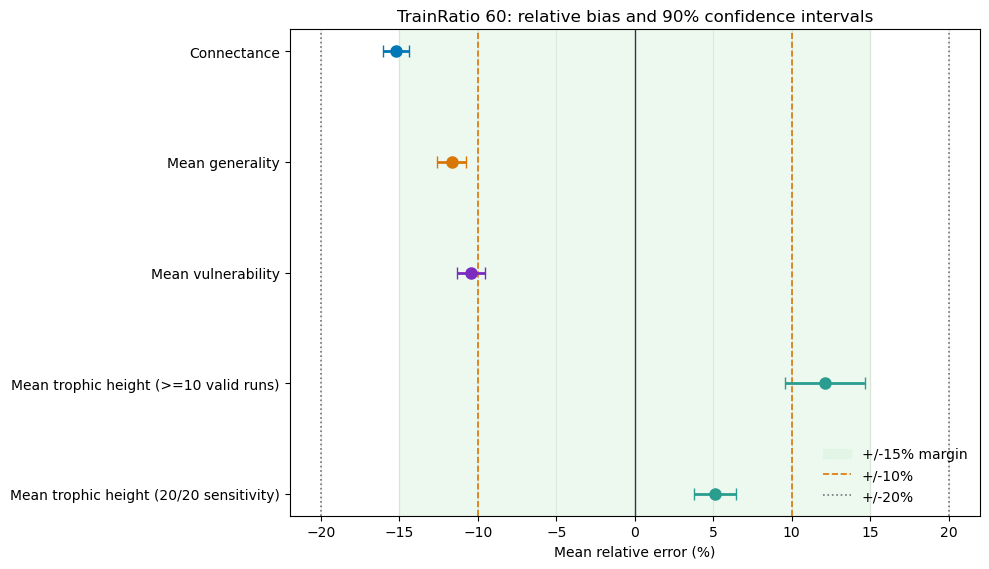

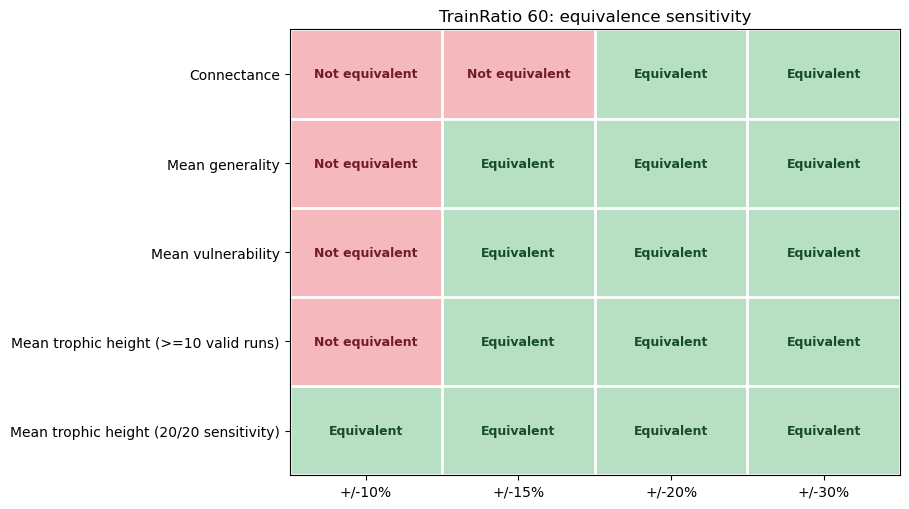

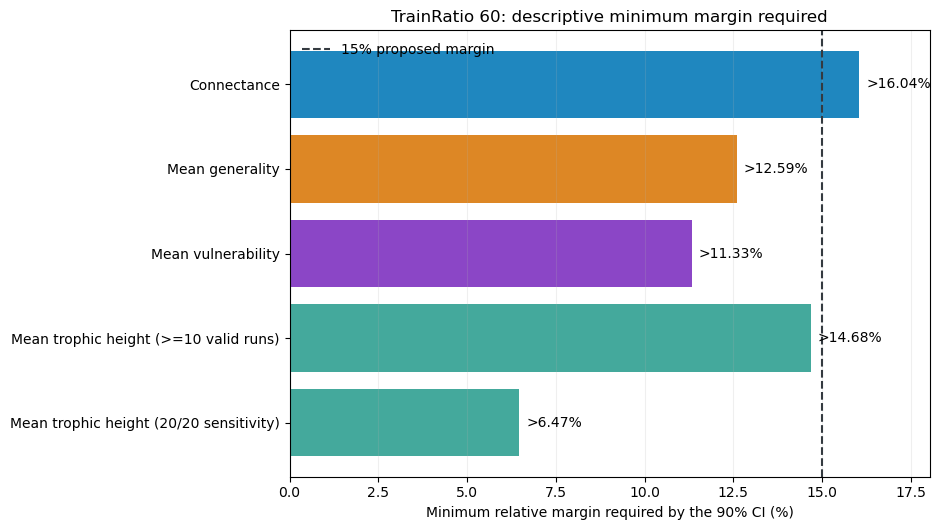

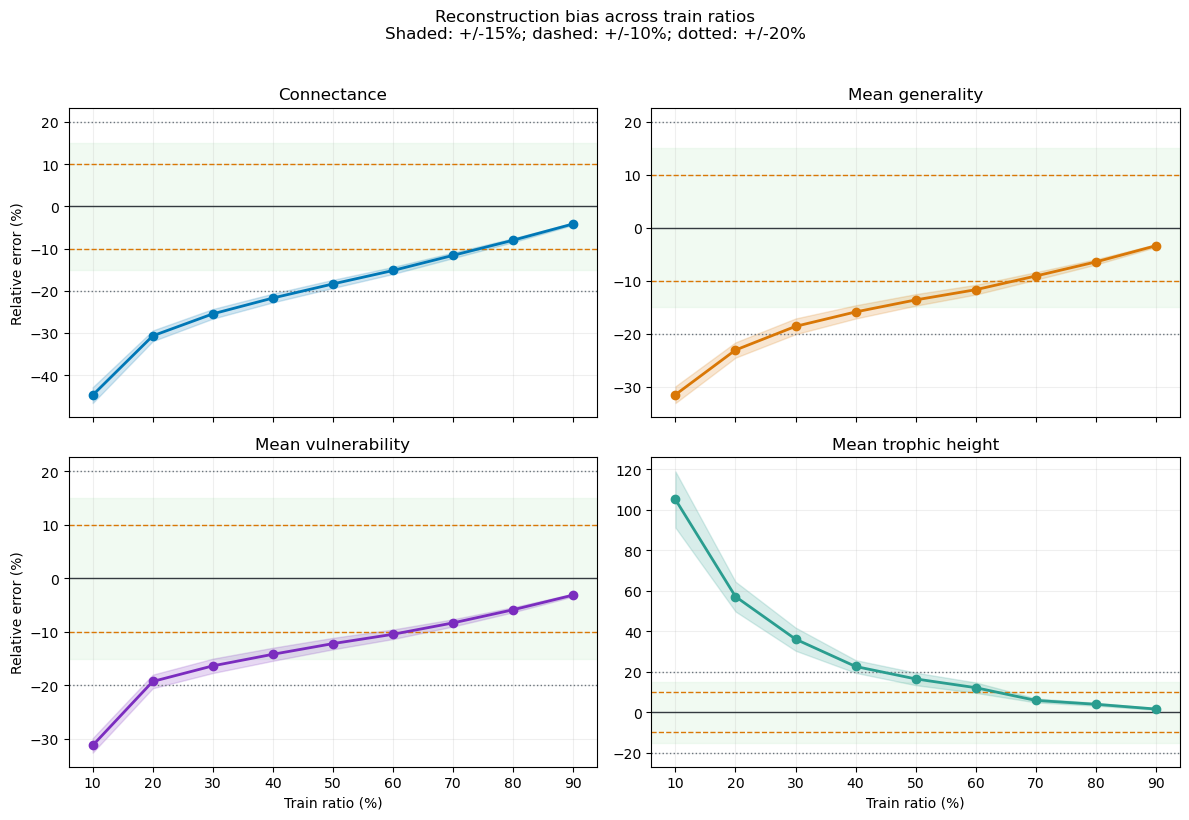

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display, Markdown


# ---------------------------------------------------------------------
# Paths and data
# ---------------------------------------------------------------------
def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src" / "matlab").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


ROOT = find_repo_root()

ATHEN_DIR = (
    ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita"
    / "statistical_tests/athen"
)

FIGURE_DIR = ATHEN_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

SAVE_FIGURES = True
MARGINS = [10, 15, 20, 30]

eq60 = pd.read_csv(ATHEN_DIR / "athen_equivalence_sensitivity_train60.csv")
eq_all = pd.read_csv(ATHEN_DIR / "athen_equivalence_sensitivity_all_ratios.csv")
minimum60 = pd.read_csv(ATHEN_DIR / "athen_minimum_margin_required_train60.csv")

METRIC_LABELS = {
    "Connectance": "Connectance",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
    "MeanTrophicHeight": "Mean trophic height",
}

METRIC_COLORS = {
    "Connectance": "#0077b6",
    "MeanGenerality": "#d97706",
    "MeanVulnerability": "#7b2cbf",
    "MeanTrophicHeight": "#2a9d8f",
}


def finish_figure(fig, filename):
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(
            FIGURE_DIR / filename,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )
    plt.show()


# ---------------------------------------------------------------------
# Select primary and trophic sensitivity populations
# ---------------------------------------------------------------------
selected = eq60[
    (eq60["AnalysisPopulation"] == "PrimaryMean20")
    | (eq60["AnalysisPopulation"] == "ConditionalAtLeast10ValidRuns")
    | (eq60["AnalysisPopulation"] == "Complete20Sensitivity")
].copy()

selected["DisplayMetric"] = selected["Metric"].map(METRIC_LABELS)

selected.loc[
    selected["AnalysisPopulation"] == "ConditionalAtLeast10ValidRuns",
    "DisplayMetric",
] = "Mean trophic height (>=10 valid runs)"

selected.loc[
    selected["AnalysisPopulation"] == "Complete20Sensitivity",
    "DisplayMetric",
] = "Mean trophic height (20/20 sensitivity)"

PLOT_ORDER = [
    "Connectance",
    "Mean generality",
    "Mean vulnerability",
    "Mean trophic height (>=10 valid runs)",
    "Mean trophic height (20/20 sensitivity)",
]


# ---------------------------------------------------------------------
# Results table
# ---------------------------------------------------------------------
descriptive = (
    selected
    .drop_duplicates(["DisplayMetric", "AnalysisPopulation"])
    [[
        "DisplayMetric",
        "AnalysisPopulation",
        "NumFoodWebs",
        "MeanEmpirical",
        "MeanPseudo",
        "MeanDelta",
        "MeanRelativeErrorPercent",
        "RelativeCI90LowerPercent",
        "RelativeCI90UpperPercent",
    ]]
    .copy()
)

descriptive["90% CI"] = descriptive.apply(
    lambda row: (
        f"[{row['RelativeCI90LowerPercent']:.2f}%, "
        f"{row['RelativeCI90UpperPercent']:.2f}%]"
    ),
    axis=1,
)

sensitivity = selected.pivot(
    index="DisplayMetric",
    columns="MarginPercent",
    values="Equivalent",
).reset_index()

sensitivity = sensitivity.rename(
    columns={margin: f"Eq +/-{margin}%" for margin in MARGINS}
)

summary = descriptive.merge(sensitivity, on="DisplayMetric", how="left")

summary = summary.rename(
    columns={
        "DisplayMetric": "Metric",
        "AnalysisPopulation": "Population",
        "NumFoodWebs": "N webs",
        "MeanEmpirical": "Empirical mean",
        "MeanPseudo": "Pseudo mean",
        "MeanDelta": "Mean delta",
        "MeanRelativeErrorPercent": "Relative bias (%)",
    }
)

equivalence_columns = [f"Eq +/-{margin}%" for margin in MARGINS]

for column in equivalence_columns:
    summary[column] = summary[column].map({1: "Yes", 0: "No"})


def shade_equivalence(column):
    return [
        (
            "background-color: #d8f3dc; color: #174c2b; font-weight: 600"
            if value == "Yes"
            else "background-color: #f8d7da; color: #721c24; font-weight: 600"
        )
        for value in column
    ]


display(Markdown("## TrainRatio 60: equivalence sensitivity"))

display(
    summary[
        [
            "Metric",
            "Population",
            "N webs",
            "Empirical mean",
            "Pseudo mean",
            "Mean delta",
            "Relative bias (%)",
            "90% CI",
            *equivalence_columns,
        ]
    ]
    .style
    .format(
        {
            "Empirical mean": "{:.4f}",
            "Pseudo mean": "{:.4f}",
            "Mean delta": "{:+.4f}",
            "Relative bias (%)": "{:+.2f}",
        }
    )
    .apply(shade_equivalence, subset=equivalence_columns)
)


# ---------------------------------------------------------------------
# Forest plot highlighting the proposed 15% margin
# ---------------------------------------------------------------------
forest = selected[selected["MarginPercent"] == 15].copy()

forest["PlotOrder"] = forest["DisplayMetric"].map(
    {name: index for index, name in enumerate(PLOT_ORDER)}
)
forest = forest.sort_values("PlotOrder", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5.8))

ax.axvspan(-15, 15, color="#d8f3dc", alpha=0.45, label="+/-15% margin")
ax.axvline(-10, color="#d97706", linestyle="--", linewidth=1.2)
ax.axvline(10, color="#d97706", linestyle="--", linewidth=1.2, label="+/-10%")
ax.axvline(-20, color="#6c757d", linestyle=":", linewidth=1.2)
ax.axvline(20, color="#6c757d", linestyle=":", linewidth=1.2, label="+/-20%")
ax.axvline(0, color="#343a40", linewidth=1)

for y, (_, row) in enumerate(forest.iterrows()):
    mean = row["MeanRelativeErrorPercent"]
    lower = row["RelativeCI90LowerPercent"]
    upper = row["RelativeCI90UpperPercent"]

    ax.errorbar(
        mean,
        y,
        xerr=[[mean - lower], [upper - mean]],
        fmt="o",
        color=METRIC_COLORS[row["Metric"]],
        ecolor=METRIC_COLORS[row["Metric"]],
        markersize=8,
        capsize=4,
        linewidth=2,
    )

ax.set_yticks(range(len(forest)))
ax.set_yticklabels(forest["DisplayMetric"])
ax.set_xlabel("Mean relative error (%)")
ax.set_title("TrainRatio 60: relative bias and 90% confidence intervals")
ax.grid(axis="x", alpha=0.25)
ax.legend(frameon=False, loc="lower right")

finish_figure(fig, "athen_train60_relative_error_forest.png")


# ---------------------------------------------------------------------
# Equivalence sensitivity matrix: 10%, 15%, 20%, 30%
# ---------------------------------------------------------------------
heat = selected.pivot(
    index="DisplayMetric",
    columns="MarginPercent",
    values="Equivalent",
).reindex(PLOT_ORDER)[MARGINS]

fig, ax = plt.subplots(figsize=(9.2, 5.2))

ax.imshow(
    heat.values,
    cmap=ListedColormap(["#f4b8bd", "#b7dfc4"]),
    vmin=0,
    vmax=1,
    aspect="auto",
)

ax.set_xticks(range(len(MARGINS)))
ax.set_xticklabels([f"+/-{margin}%" for margin in MARGINS])
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title("TrainRatio 60: equivalence sensitivity")

for row_index in range(heat.shape[0]):
    for column_index in range(heat.shape[1]):
        value = int(heat.iloc[row_index, column_index])

        ax.text(
            column_index,
            row_index,
            "Equivalent" if value else "Not equivalent",
            ha="center",
            va="center",
            fontsize=9,
            color="#174c2b" if value else "#721c24",
            fontweight="bold",
        )

ax.set_xticks(np.arange(-0.5, len(MARGINS), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heat.index), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

finish_figure(fig, "athen_train60_equivalence_sensitivity.png")


# ---------------------------------------------------------------------
# Minimum descriptive margin required
# ---------------------------------------------------------------------
minimum = minimum60.copy()

minimum["DisplayMetric"] = minimum["Metric"].map(METRIC_LABELS)

minimum.loc[
    minimum["AnalysisPopulation"] == "ConditionalAtLeast10ValidRuns",
    "DisplayMetric",
] = "Mean trophic height (>=10 valid runs)"

minimum.loc[
    minimum["AnalysisPopulation"] == "Complete20Sensitivity",
    "DisplayMetric",
] = "Mean trophic height (20/20 sensitivity)"

minimum["PlotOrder"] = minimum["DisplayMetric"].map(
    {name: index for index, name in enumerate(PLOT_ORDER)}
)
minimum = minimum.sort_values("PlotOrder", ascending=False)

fig, ax = plt.subplots(figsize=(9.5, 5.4))

colors = [METRIC_COLORS[metric] for metric in minimum["Metric"]]

bars = ax.barh(
    minimum["DisplayMetric"],
    minimum["MinimumMarginPercentExclusive"],
    color=colors,
    alpha=0.88,
)

ax.axvline(
    15,
    color="#343a40",
    linestyle="--",
    linewidth=1.5,
    label="15% proposed margin",
)

for bar, value in zip(bars, minimum["MinimumMarginPercentExclusive"]):
    ax.text(
        value + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f">{value:.2f}%",
        va="center",
    )

ax.set_xlabel("Minimum relative margin required by the 90% CI (%)")
ax.set_title("TrainRatio 60: descriptive minimum margin required")
ax.set_xlim(0, max(18, minimum["MinimumMarginPercentExclusive"].max() + 2))
ax.grid(axis="x", alpha=0.2)
ax.legend(frameon=False)

finish_figure(fig, "athen_train60_minimum_margin_required.png")


# ---------------------------------------------------------------------
# Relative bias across train ratios, with 15% highlighted
# ---------------------------------------------------------------------
trend = eq_all[
    (eq_all["MarginPercent"] == 15)
    & (eq_all["AnalysisPopulation"] != "Complete20Sensitivity")
].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for ax, metric in zip(axes, METRIC_LABELS):
    data = trend[trend["Metric"] == metric].sort_values("TrainRatio")
    color = METRIC_COLORS[metric]

    ax.axhspan(-15, 15, color="#d8f3dc", alpha=0.35)
    ax.axhline(-10, color="#d97706", linestyle="--", linewidth=1)
    ax.axhline(10, color="#d97706", linestyle="--", linewidth=1)
    ax.axhline(-20, color="#6c757d", linestyle=":", linewidth=1)
    ax.axhline(20, color="#6c757d", linestyle=":", linewidth=1)
    ax.axhline(0, color="#343a40", linewidth=1)

    ax.plot(
        data["TrainRatio"],
        data["MeanRelativeErrorPercent"],
        color=color,
        marker="o",
        linewidth=2,
    )

    ax.fill_between(
        data["TrainRatio"],
        data["RelativeCI90LowerPercent"],
        data["RelativeCI90UpperPercent"],
        color=color,
        alpha=0.18,
    )

    ax.set_title(METRIC_LABELS[metric])
    ax.set_xticks(range(10, 100, 10))
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Relative error (%)")
axes[2].set_ylabel("Relative error (%)")
axes[2].set_xlabel("Train ratio (%)")
axes[3].set_xlabel("Train ratio (%)")

fig.suptitle(
    "Reconstruction bias across train ratios\n"
    "Shaded: +/-15%; dashed: +/-10%; dotted: +/-20%",
    y=1.02,
)

finish_figure(fig, "athen_relative_error_all_train_ratios.png")

1. Fix method to calculate trophic height using networkx

2. Calculate the 4 metrics for the Mill Stream from the Ledger et al. Es posible calcular la version no ponderada teniendo la version ponderada.

3. Calcular SEM

4. Mean trophic height

5. Columna K is comparable with column C (SEM)

6. The test is a sanity test

7. The test show that 2 correspond to each other



---



Fig 5, remove all the stacks, remove p and delta values

Add the description of the statistics to the method manuscript

## Mill Stream benchmarks

,Metric,Mean,SEM,Relative SEM (%),Definition
0,Connectance,0.0900,0.0100,11.11%,L / S^2 (unweighted)
1,Mean generality,11.6800,1.1100,9.50%,L / number of consumers (unweighted)
2,Mean vulnerability,6.6300,0.6300,9.50%,L / number of resources (unweighted)
3,Mean trophic height,1.5400,0.0040,0.26%,Prey-averaged trophic level; basal species included at level 1


## TrainRatio 60: overall results

,Metric,N webs,Empirical mean,Mean pseudo,Mean delta,Mean relative error (90% CI),Ledger relative SEM (%),Corresponds?
0,Connectance,290,0.1283,0.1090,-0.0193,"-15.19% [-16.03%, -14.35%]",11.11%,False
1,Mean generality,290,10.5418,9.0060,-1.5358,"-11.68% [-12.59%, -10.76%]",9.50%,False
2,Mean vulnerability,290,8.2909,7.1990,-1.0919,"-10.43% [-11.32%, -9.54%]",9.50%,False
3,Mean trophic height,290,2.1898,2.5425,+0.3526,"+11.56% [+8.99%, +14.12%]",0.26%,False


## Lakes

...

,Metric,N webs,Empirical mean,Mean pseudo,Mean delta,Mean relative error (90% CI),Ledger relative SEM (%),Corresponds?
3,Connectance,21,0.0999,0.0868,-0.0130,"-12.12% [-15.68%, -8.56%]",11.11%,False
8,Mean generality,21,11.7948,10.7295,-1.0653,"-10.47% [-14.09%, -6.84%]",9.50%,False
13,Mean vulnerability,21,8.7144,7.5901,-1.1243,"-11.28% [-14.87%, -7.69%]",9.50%,False
18,Mean trophic height,21,2.4018,2.7807,+0.3789,"+13.83% [+7.20%, +20.47%]",0.26%,False


## Terrestrial belowground

,Metric,N webs,Empirical mean,Mean pseudo,Mean delta,Mean relative error (90% CI),Ledger relative SEM (%),Corresponds?
4,Connectance,52,0.1141,0.0961,-0.0180,"-15.82% [-16.76%, -14.89%]",11.11%,False
9,Mean generality,52,15.1657,13.0091,-2.1566,"-14.27% [-15.35%, -13.19%]",9.50%,False
14,Mean vulnerability,52,15.1244,13.0798,-2.0446,"-13.42% [-14.62%, -12.22%]",9.50%,False
19,Mean trophic height,52,3.3558,4.6004,+1.2447,"+36.02% [+28.31%, +43.73%]",0.26%,False


## Figures

### Ledger Train60 Overall Relative Error

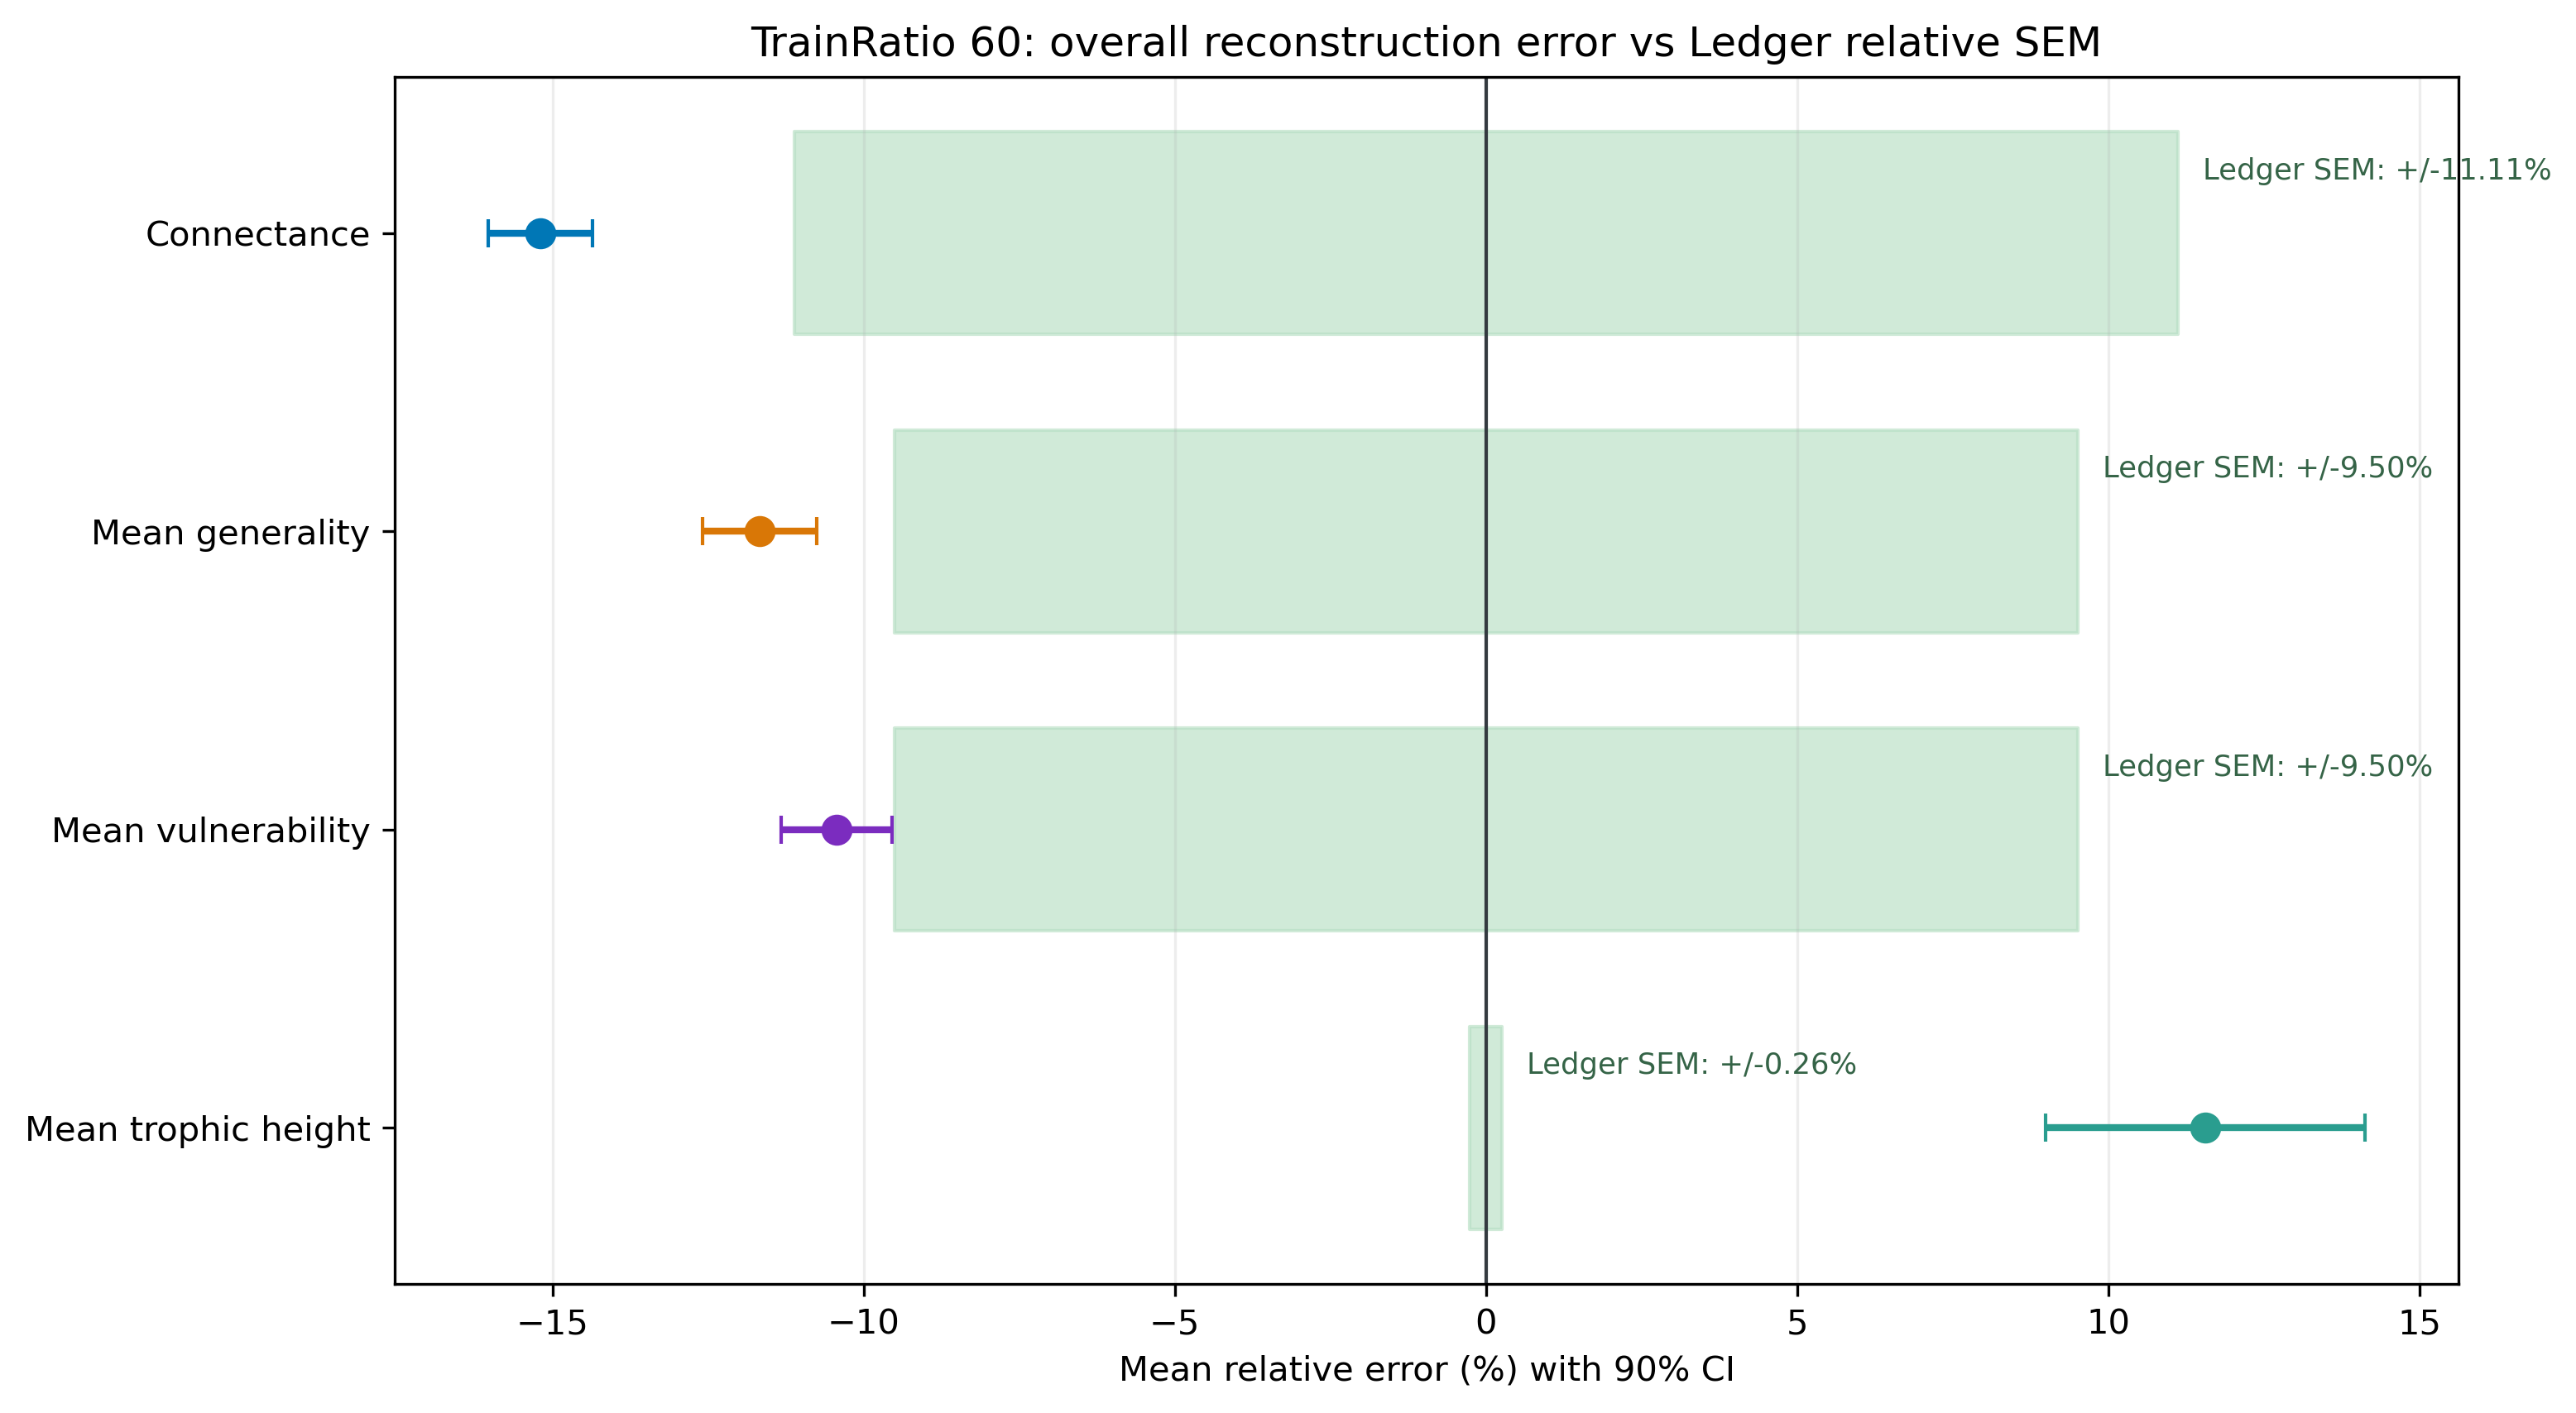

### Ledger Train60 Ecosystem Relative Error

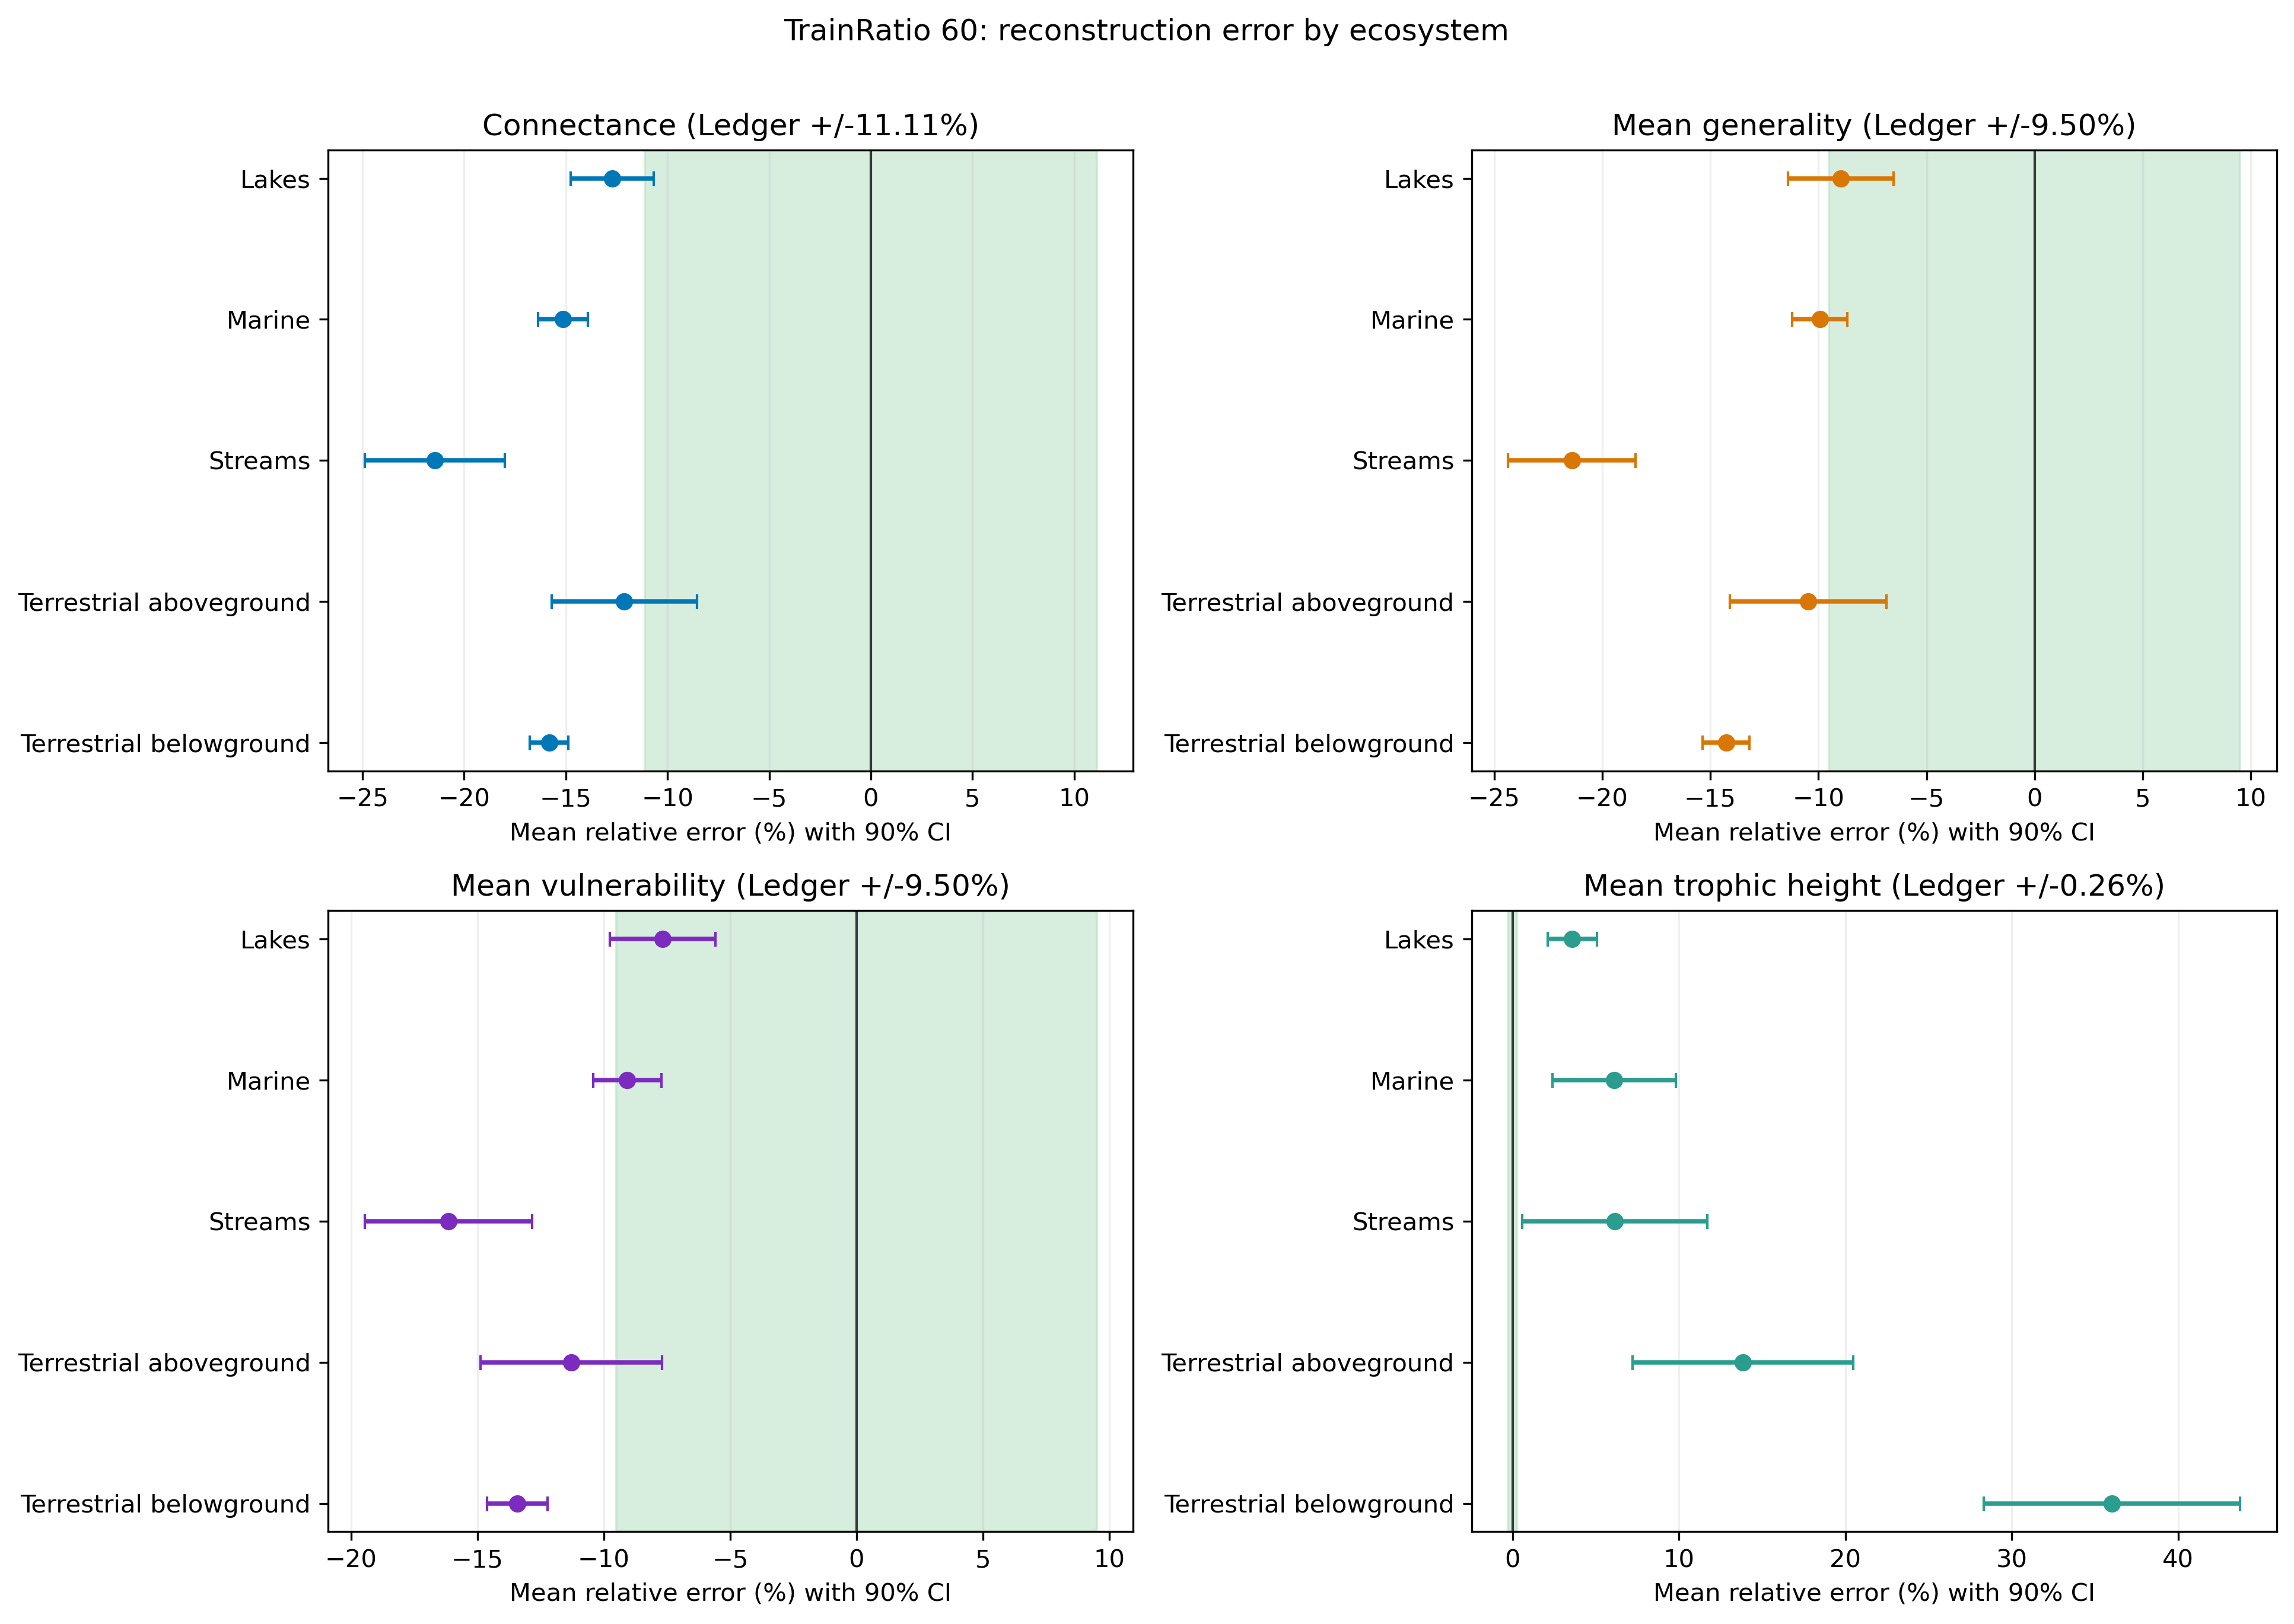

### Ledger Train60 Ecosystem Error Heatmap

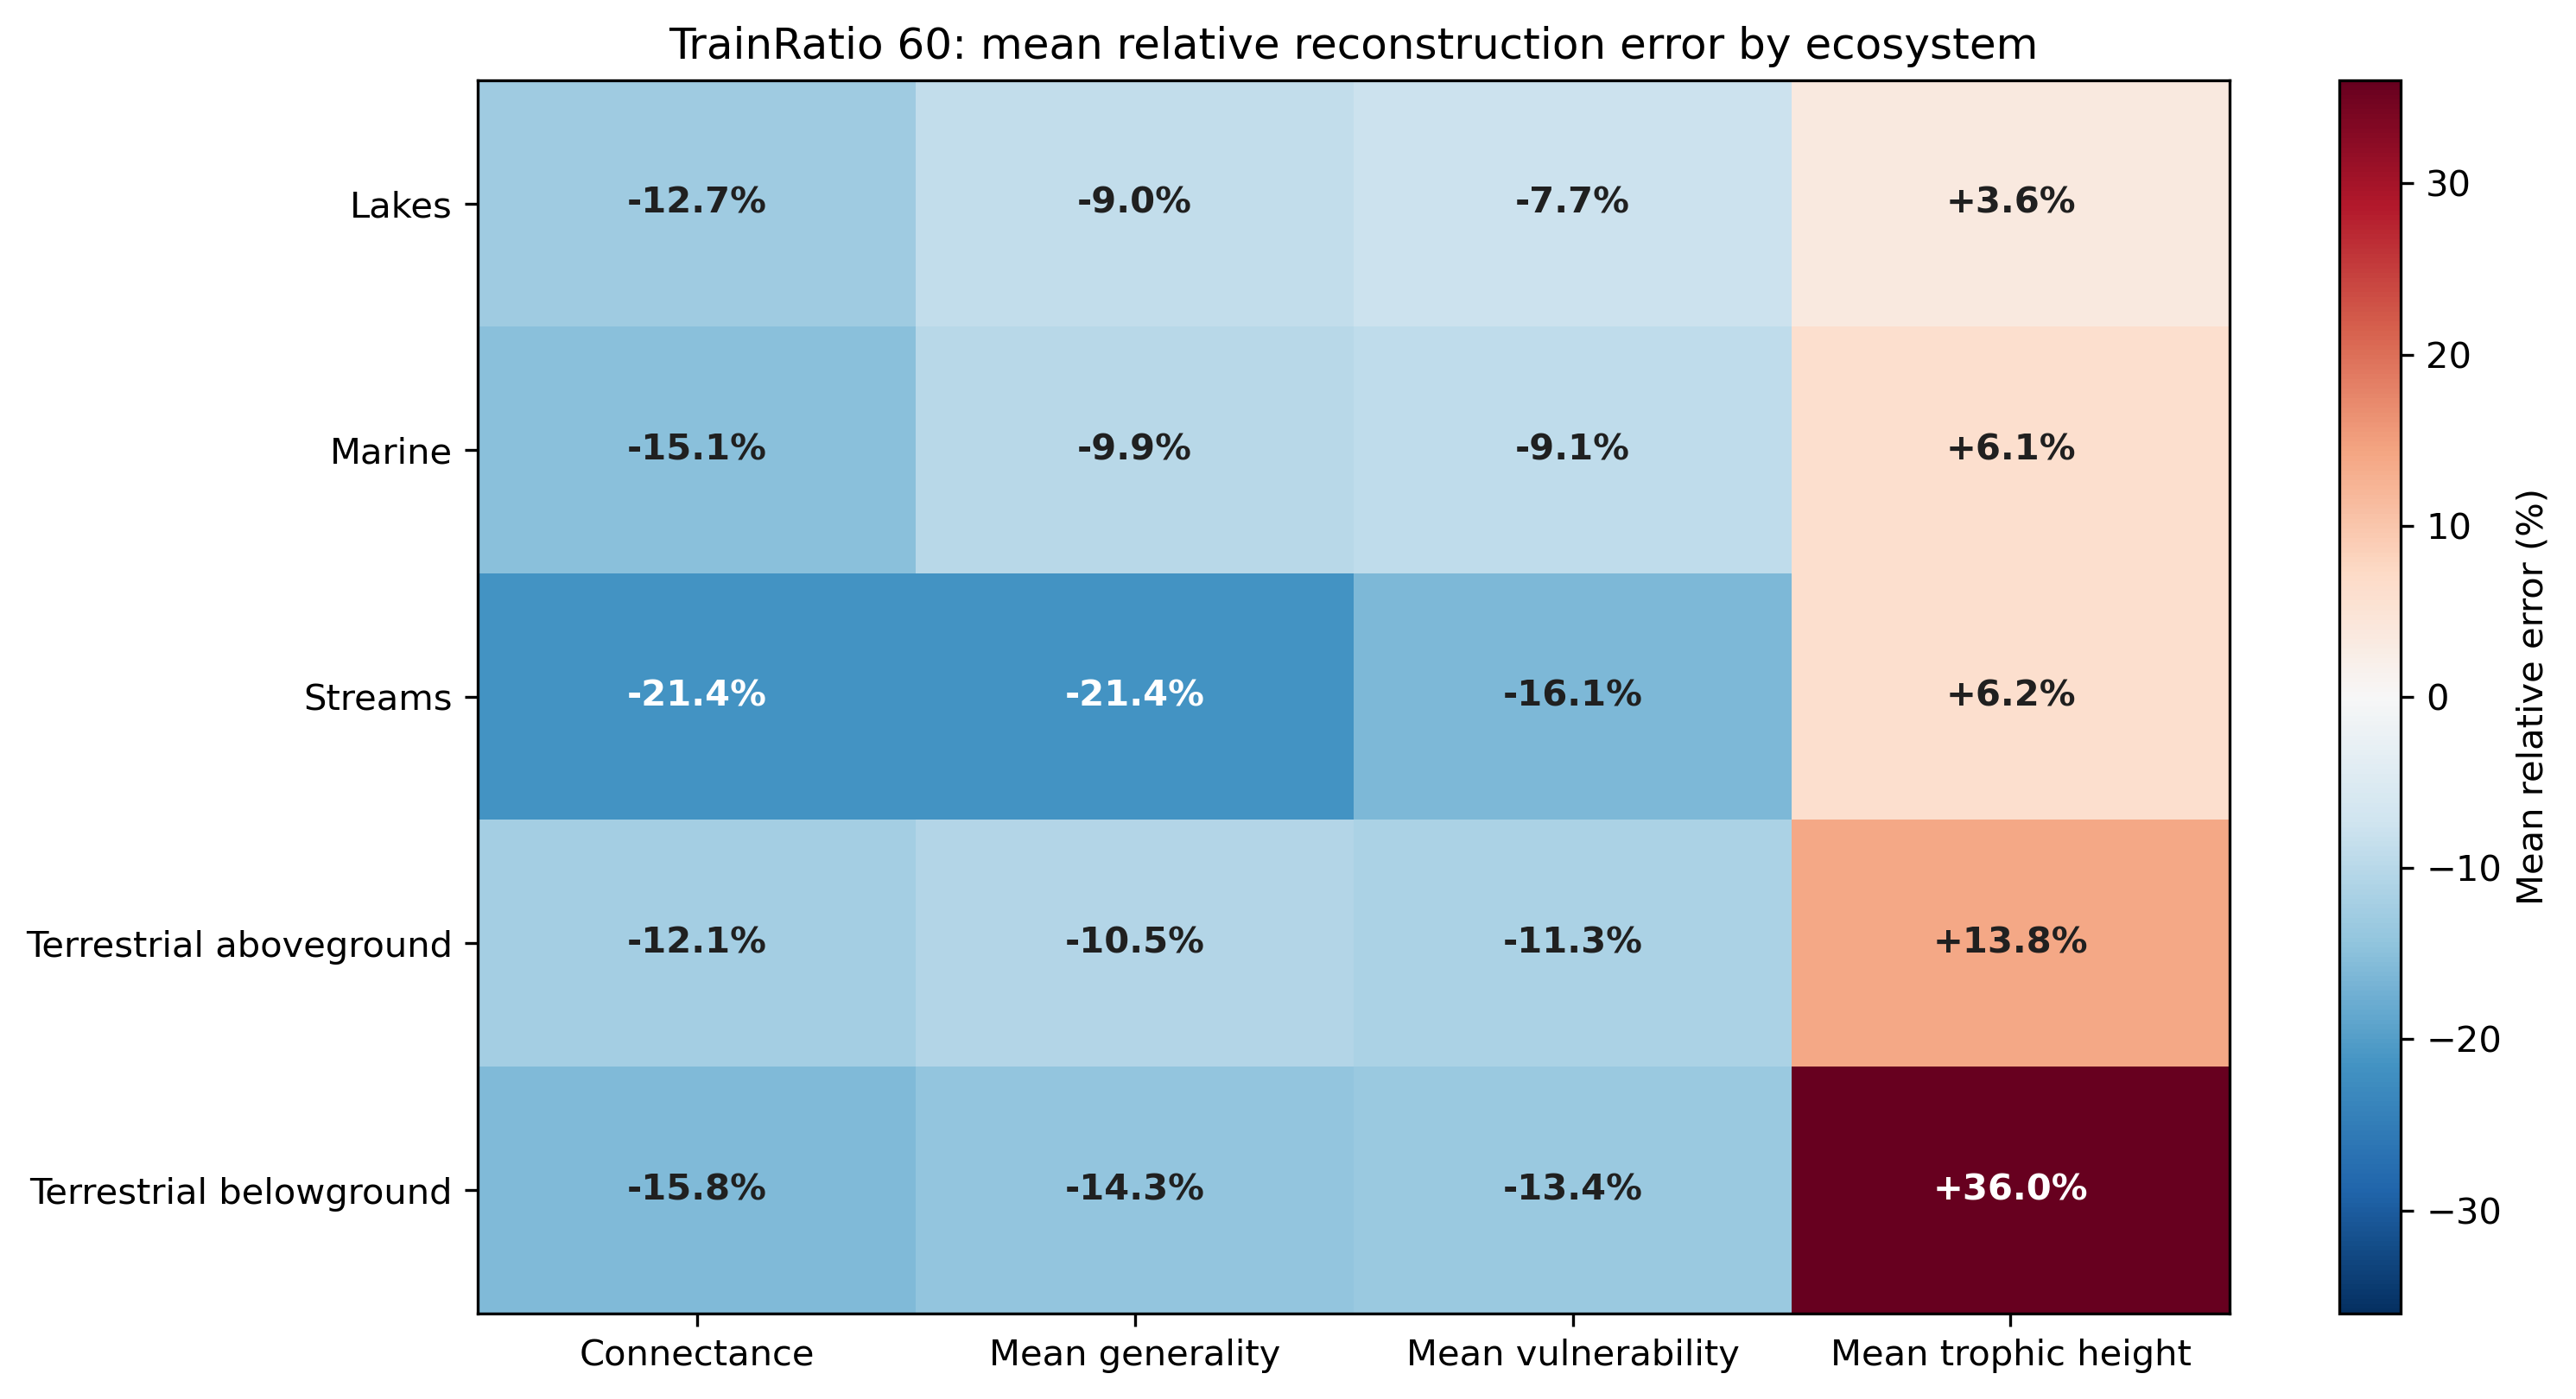

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display, Markdown, Image


# Locate repository root
root = Path.cwd().resolve()
while root != root.parent and not (root / "src/matlab").exists():
    root = root.parent

DATA_DIR = (
    root
    / "src/matlab/data/"
    "result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita/"
    "statistical_tests/athen/ledger_sanity"
)
FIGURE_DIR = DATA_DIR / "figures"

benchmarks = pd.read_csv(DATA_DIR / "ledger_benchmarks.csv")
overall = pd.read_csv(DATA_DIR / "ledger_sanity_train60_overall.csv")
ecosystems = pd.read_csv(DATA_DIR / "ledger_sanity_train60_by_ecosystem.csv")
excel_table = pd.read_csv(DATA_DIR / "ledger_excel_table_train60.csv")


def conclusion_colour(value):
    return (
        "background-color: #d7f5dd; color: #174c2b"
        if bool(value)
        else "background-color: #f8d7da; color: #721c24"
    )


# Ledger benchmarks
display(Markdown("## Mill Stream benchmarks"))

benchmark_view = benchmarks[
    ["MetricLabel", "Mean", "SEM", "RelativeSEMPercent", "Definition"]
].rename(columns={
    "MetricLabel": "Metric",
    "RelativeSEMPercent": "Relative SEM (%)",
})

display(
    benchmark_view.style.format({
        "Mean": "{:.4f}",
        "SEM": "{:.4f}",
        "Relative SEM (%)": "{:.2f}%",
    })
)


# Overall TrainRatio 60 results
display(Markdown("## TrainRatio 60: overall results"))

overall_view = overall[[
    "MetricLabel",
    "NumFoodWebs",
    "MeanEmpirical",
    "MeanPseudo",
    "MeanDelta",
    "RelativeError90CI",
    "LedgerRelativeSEMPercent",
    "CI90WithinLedgerRelativeSEM",
]].rename(columns={
    "MetricLabel": "Metric",
    "NumFoodWebs": "N webs",
    "MeanEmpirical": "Empirical mean",
    "MeanPseudo": "Mean pseudo",
    "MeanDelta": "Mean delta",
    "RelativeError90CI": "Mean relative error (90% CI)",
    "LedgerRelativeSEMPercent": "Ledger relative SEM (%)",
    "CI90WithinLedgerRelativeSEM": "Corresponds?",
})

overall_view["Corresponds?"] = overall_view["Corresponds?"].astype(bool)

display(
    overall_view.style
    .format({
        "Empirical mean": "{:.4f}",
        "Mean pseudo": "{:.4f}",
        "Mean delta": "{:+.4f}",
        "Ledger relative SEM (%)": "{:.2f}%",
    })
    .map(conclusion_colour, subset=["Corresponds?"])
)


# Results by ecosystem
ecosystem_labels = {
    "lakes": "Lakes",
    "marine": "Marine",
    "streams": "Streams",
    "terrestrial aboveground": "Terrestrial aboveground",
    "terrestrial belowground": "Terrestrial belowground",
}

for ecosystem, label in ecosystem_labels.items():
    display(Markdown(f"## {label}"))

    subset = ecosystems[
        ecosystems["EcosystemType"].eq(ecosystem)
    ][[
        "MetricLabel",
        "NumFoodWebs",
        "MeanEmpirical",
        "MeanPseudo",
        "MeanDelta",
        "RelativeError90CI",
        "LedgerRelativeSEMPercent",
        "CI90WithinLedgerRelativeSEM",
    ]].rename(columns={
        "MetricLabel": "Metric",
        "NumFoodWebs": "N webs",
        "MeanEmpirical": "Empirical mean",
        "MeanPseudo": "Mean pseudo",
        "MeanDelta": "Mean delta",
        "RelativeError90CI": "Mean relative error (90% CI)",
        "LedgerRelativeSEMPercent": "Ledger relative SEM (%)",
        "CI90WithinLedgerRelativeSEM": "Corresponds?",
    })

    subset["Corresponds?"] = subset["Corresponds?"].astype(bool)

    display(
        subset.style
        .format({
            "Empirical mean": "{:.4f}",
            "Mean pseudo": "{:.4f}",
            "Mean delta": "{:+.4f}",
            "Ledger relative SEM (%)": "{:.2f}%",
        })
        .map(conclusion_colour, subset=["Corresponds?"])
    )


# Generated figures
figure_files = [
    "ledger_train60_overall_relative_error.png",
    "ledger_train60_ecosystem_relative_error.png",
    "ledger_train60_ecosystem_error_heatmap.png",
]

display(Markdown("## Figures"))

for filename in figure_files:
    path = FIGURE_DIR / filename
    display(Markdown(f"### {path.stem.replace('_', ' ').title()}"))
    display(Image(filename=str(path), width=1100))